# 29 · E1p: the whole ladder, converged — E1's final decision

**Where Notebook 28 left off.** With every model fitted cleanly *and to convergence* (warm-restarted cycles, `ladder.fit_cycles`):

| held-out FEVE | L0 | `L1c` (sigmoid, class weights) | `L0w` (linear, per-synapse weights) |
|---|---|---|---|
| both strains | 0.428 | 0.430 | 0.429 |

* **Per-synapse weights add nothing** to a converged linear model. `L0w` refused to move its weights on 4 of 5 folds.
* **The nonlinearity neither helps nor hurts.** Notebook 26's "`L1c` is 0.096 worse" was under-optimization and is withdrawn.
* **Every E1 comparison so far mixed mechanism with optimization.** That includes Notebook 25's finding that L1–L4 and the black box are 0.1 below L0. Those rungs were fitted with a fixed budget, never to convergence.

**This notebook closes E1.** The whole ladder is fitted the way Notebook 28 fitted its three models: on the same inner-training pairs, converged by warm-restarted cycles with early stopping on the same unseen validation pairs. Then E1's three rules and its black-box rule are applied one last time.
* **L0, `L0w`, `L1c`:** Notebook 28's fits. A model that did not converge there (fold 2) gets further cycles.
* **L1:** grown from the converged `L1c`, with its class weights written out per synapse (`ladder.l1_from_l1c`, package 0.24). It starts where `L1c` ended and may then tune each synapse.
* **L1s, L2:** grown from the converged L1, as in E1's nested chain. L2's new mechanism starts nearly off; L1s's slow current starts at ρ = 0.1, τ_n = 10 s (Notebook 24's choice).
* **L3, L4:** grown from the converged L2 and L3, in turn.
* **B (the black box):** from scratch, converged the same way.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, pickle, time, datetime, numpy as np, matplotlib.pyplot as plt, jax, jax.numpy as jnp
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 24, 0), \
    f"Notebook 29 needs closurebench >= 0.24.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M_
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
N_BOOT, THRESHOLD, VAL_FRAC = 2000, 0.05, 0.2
TAG = "" if MODE == "full" else f"_{MODE}"
E1_TAG = "_laptop" if MODE == "smoke" else TAG
PRIOR = "laptop" if MODE == "smoke" else MODE
MECH = ("L0", "L1c", "L0w", "L1", "L1s", "L2", "L3", "L4")
RUNGS = MECH + ("B",)
LADDER_E1 = ("L0", "L1", "L2", "L3", "L4")
CYC = {"smoke": dict(CYCLE_STEPS=30, MAX_CYCLES=3, MORE_CYCLES=2, EVAL_EVERY=10, PATIENCE=2, TOL=1e-3),
       "laptop": dict(CYCLE_STEPS=1000, MAX_CYCLES=6, MORE_CYCLES=4, EVAL_EVERY=100, PATIENCE=5, TOL=1e-3),
       "full": dict(CYCLE_STEPS=1500, MAX_CYCLES=8, MORE_CYCLES=4, EVAL_EVERY=100, PATIENCE=5, TOL=1e-3)}[MODE]; globals().update(CYC)
SLOW_START = (0.1, 10.0)

def to_np(p):
    q = jax.tree_util.tree_map(np.asarray, dict(p))
    if "n_heads" in q: q["n_heads"] = int(q["n_heads"])
    return q
def to_jnp(p):
    q = {k: (v if k == "n_heads" else jax.tree_util.tree_map(jnp.asarray, v)) for k, v in dict(p).items()}
    if "n_heads" in q: q["n_heads"] = int(q["n_heads"])
    return q

try:
    e1_result = json.load(open(os.path.join(RESULTS, f"E1_result{E1_TAG}.json")))
    c = json.load(open(os.path.join(RESULTS, e1_result["preregistration"])))["config"]
    ds = D.Dataset.load(os.path.join(RESULTS, "atlas_dataset.npz"))
    if c["n_neurons"] < ds.N:
        mk = ds.mask()[0]; score = mk.sum(1).astype(float); score[ds.stim] += mk.sum(0)
        ds = D.subset(ds, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    st = lad.Structure.from_dataset(ds, tie=c["tie_classes"]); cfg = lad.SimConfig(**c["sim"])
    folds = M_.kfold_pairs(ds, c["k_folds"], c["fold_seed"]); LR = float(c.get("lr", 1e-2))
    ck28 = os.path.join(RESULTS, "e1o_ck", PRIOR)
    PRIOR28 = [{L: pickle.load(open(os.path.join(ck28, f"fold{f}_{L}.pkl"), "rb")) for L in ("L0", "L0w", "L1c")}
               for f in range(len(folds))]
    P25 = dict(np.load(os.path.join(RESULTS, f"E1l_heldout_predictions{E1_TAG}.npz")))
    d9 = os.path.join(RESULTS, f"E1e_result{E1_TAG}.json")
    DELTA = json.load(open(d9))["delta"] if os.path.exists(d9) else {}
    SOURCE = f"E1 ({E1_TAG.strip('_') or 'full'}) data and folds; Notebook 28's converged L0 / L0w / L1c"
except (FileNotFoundError, KeyError) as err:
    if MODE != "smoke":
        raise
    print("Notebook 28 results not found (", err, ") -> CODE-PATH TEST ONLY on a synthetic worm")
    ds, p_true, _ = lad.make_synthetic(lad.random_wiring(N=24, S=10, seed=1), true_level="L1", seed=1)
    st = lad.Structure.from_dataset(ds); cfg = lad.SimConfig(); folds = M_.kfold_pairs(ds, 2, 0); LR = 1e-2
    PRIOR28 = None; P25 = None; DELTA = {"repeat": 0.01}; SOURCE = "synthetic (code path only)"
COUNT = {L: lad.trainable_count(L, st) for L in MECH}
LADDER_ALL = tuple(sorted(MECH, key=COUNT.get))
print(f"source: {SOURCE} | {ds.N} neurons, {ds.S} stimuli | {len(folds)} folds | lr {LR} | {CYC}")
print("free parameters:", COUNT, "\nextended ladder (by parameters):", LADDER_ALL)

source: E1 (laptop) data and folds; Notebook 28's converged L0 / L0w / L1c | 120 neurons, 120 stimuli | 5 folds | lr 0.02 | {'CYCLE_STEPS': 1000, 'MAX_CYCLES': 6, 'MORE_CYCLES': 4, 'EVAL_EVERY': 100, 'PATIENCE': 5, 'TOL': 0.001}
free parameters: {'L0': 126, 'L1c': 345, 'L0w': 982, 'L1': 1124, 'L1s': 1126, 'L2': 1417, 'L3': 1564, 'L4': 1711} 
extended ladder (by parameters): ('L0', 'L1c', 'L0w', 'L1', 'L1s', 'L2', 'L3', 'L4')


### Pre-registration (before §1)

Recorded in `results/E1p_preregistration*.json`. The outer folds, metric, bootstrap and inner split are as in Notebooks 26–28.

**Fitting.** Every model is fitted on the inner-training pairs with `ladder.fit_cycles`: early-stopped cycles of at most `CYCLE_STEPS` steps, each restarted from the best point with a fresh schedule, until a cycle fails to lower the validation loss by `TOL`, or after `MAX_CYCLES`. Starts:
* **L0, `L0w`, `L1c`:** Notebook 28's fits. If one did not converge there, it gets up to `MORE_CYCLES` further cycles.
* **L1:** `l1_from_l1c`(converged `L1c`).
* **L1s:** the converged L1 with a slow current at ρ = 0.1, τ_n = 10 s.
* **L2:** the converged L1 with its mechanism nearly off (E1's `extend_params`).
* **L3:** the converged L2 the same way.
* **L4:** the converged L3 the same way.
* **B:** from scratch.

**Rules.** Held-out FEVE on the outer test pairs, 95 % bootstrap CI over stimulated neurons.
* **VERDICT_L0_FINAL** (primary): on the extended ladder ordered by free parameters (L0 → … → L4), both strains, the necessity rule and v4 (every δ) give L0.
* **E1 decisions** on E1's original ladder L0 → L1 → L2 → L3 → L4, both strains and WT: sufficiency, necessity, v4.
* **OUTCOME_C / OUTCOME_C_WT:** E1's black-box rule; the 2.5th percentile of FEVE(B) − FEVE(L\*) must be > 0.05.
* **EQUIVALENT:** the rungs whose difference from L0 has a CI containing 0. These are equally good descriptions, of which E1 reports the simplest.

**Reported:** convergence of every fit, and every rung's FEVE on both strains, WT and unc-31.

In [3]:
prereg = os.path.join(RESULTS, f"E1p_preregistration{TAG}.json")
plan = {"experiment": "E1p whole ladder fitted cleanly and to convergence (fit_cycles), E1's final decision", "mode": MODE,
        "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(), "source": SOURCE,
        "rungs": list(RUNGS), "free_parameters": COUNT, "ladder_all": list(LADDER_ALL), "ladder_e1": list(LADDER_E1),
        "cycles": CYC, "slow_start": SLOW_START, "val_frac": VAL_FRAC, "inner_seed": "100 + fold", "lr": LR, "n_boot": N_BOOT,
        "VERDICT_L0_FINAL": "extended ladder, both strains: L_needed == L0 and v4 == L0 for every delta",
        "OUTCOME_C": "2.5th pct of FEVE(B) - FEVE(L*) > 0.05 (both strains / WT)",
        "EQUIVALENT": "rungs whose FEVE difference from L0 has a 95% CI containing 0"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1p_preregistration_laptop.json


## 1 · Converge the ladder (checkpointed)

The cost per fold in `laptop` mode is roughly:
* L1, L1s and L2: 5–15 min each;
* L3 and L4: 10–20 min each;
* B: 5–10 min.

Expect **4–8 h** in total, best run overnight with `scripts/run_notebook.sh`. Every converged model is saved when it finishes, and a rerun resumes.

fold 0 L1      : 0 accepted cycle(s), converged | validation loss 0.8583 | 2.6 min
fold 0 L1s     : 1 accepted cycle(s), converged | validation loss 0.8720 -> 0.8615 | 6.9 min
fold 0 L2      : 2 accepted cycle(s), converged | validation loss 0.9084 -> 0.8619 -> 0.8609 | 10.1 min
fold 0 L3      : 1 accepted cycle(s), converged | validation loss 0.8609 -> 0.8449 | 7.2 min
fold 0 L4      : 1 accepted cycle(s), converged | validation loss 0.8493 -> 0.8436 | 6.5 min
fold 0 B       : 1 accepted cycle(s), converged | validation loss 1.0007 -> 0.9006 | 3.2 min
fold 1 L1      : 1 accepted cycle(s), converged | validation loss 0.8811 -> 0.8516 | 7.2 min
fold 1 L1s     : 1 accepted cycle(s), converged | validation loss 0.8975 -> 0.8543 | 7.6 min
fold 1 L2      : 0 accepted cycle(s), converged | validation loss 0.8566 | 2.5 min
fold 1 L3      : 0 accepted cycle(s), converged | validation loss 0.8566 | 3.2 min
fold 1 L4      : 1 accepted cycle(s), converged | validation loss 0.8751 -> 0.8556 | 9.5 

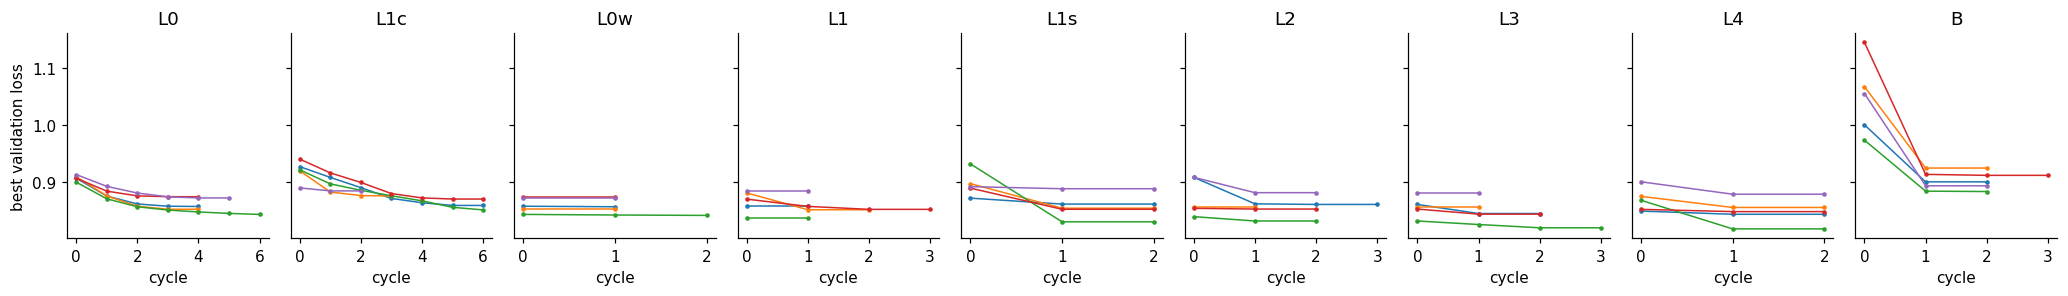

In [4]:
CK = os.path.join(RESULTS, "e1p_ck", MODE); os.makedirs(CK, exist_ok=True)
def split(f):
    test = folds[f]; train = np.zeros_like(test)
    for g in range(len(folds)):
        if g != f: train |= folds[g]
    return train, test
def inner(f):
    train = split(f)[0] & ds.mask()
    u = np.random.default_rng(100 + f).random(ds.mask().shape[1:]) < VAL_FRAC
    val = train & np.broadcast_to(u, train.shape)
    return train & ~val, val
def cyc_fit(f, name, L, init, max_cycles):
    pth = os.path.join(CK, f"fold{f}_{name}.pkl")
    if os.path.exists(pth):
        d = pickle.load(open(pth, "rb")); return d["params"], d["info"]
    itr, val = inner(f); t0 = time.time()
    p, info = lad.fit_cycles(L, ds, None if init is None else to_jnp(init), itr, val, steps=CYCLE_STEPS, max_cycles=max_cycles,
                             tol=TOL, eval_every=EVAL_EVERY, patience=PATIENCE, lr=LR, st=st, cfg=cfg, seed=f)
    info = dict(info, seconds=time.time() - t0); p = to_np(p)
    pickle.dump({"params": p, "info": info}, open(pth, "wb"))
    vs = [info["cycles"][0]["val_start"]] + [c["val_best"] for c in info["cycles"] if c["accepted"]]
    print(f"fold {f} {name:8s}: {info['n_accepted']} accepted cycle(s), {'converged' if info['converged'] else 'MAX_CYCLES reached'} | "
          f"validation loss " + " -> ".join(f"{v:.4f}" for v in vs) + f" | {info['seconds'] / 60:.1f} min", flush=True)
    return p, info
def slow(p, rho, tau_n):
    q = lad.extend_params(to_jnp(p), "L1s", st, jax.random.PRNGKey(0))
    q["rho_s"] = jnp.array(float(np.log(rho / (0.9 - rho)))); q["tau_ns"] = jnp.array(lad.inv_sp(max(tau_n - lad.TAU_MIN, 0.05)))
    return to_np(q)
grow = lambda p, L: to_np(lad.extend_params(to_jnp(p), L, st, jax.random.PRNGKey(0)))
FITS, INFO = [], {}
for f in range(len(folds)):
    FITS.append({})
    for L in ("L0", "L0w", "L1c"):                    # Notebook 28's fits (or quick clean ones in smoke mode)
        if PRIOR28 is not None:
            d = PRIOR28[f][L]; p, info = to_np(d["params"]), dict(d["info"], source="Notebook 28")
            if not info["converged"]:
                p, more = cyc_fit(f, f"{L}_more", L, p, MORE_CYCLES)
                info = dict(info, more=more, converged=more["converged"], source="Notebook 28 + more cycles")
        else:
            init = grow(FITS[f]["L0"], "L0w") if L == "L0w" else None
            p, info = cyc_fit(f, L, L, init, MAX_CYCLES)
        FITS[f][L], INFO[(f, L)] = p, info
    chain = (("L1", lambda: to_np(lad.l1_from_l1c(to_jnp(FITS[f]["L1c"]), st))),
             ("L1s", lambda: slow(FITS[f]["L1"], *SLOW_START)), ("L2", lambda: grow(FITS[f]["L1"], "L2")),
             ("L3", lambda: grow(FITS[f]["L2"], "L3")), ("L4", lambda: grow(FITS[f]["L3"], "L4")), ("B", lambda: None))
    for L, start in chain:
        FITS[f][L], INFO[(f, L)] = cyc_fit(f, L, L, start(), MAX_CYCLES)
ALL_CONVERGED = {L: [bool(INFO[(f, L)]["converged"]) for f in range(len(folds))] for L in RUNGS}
print("\nconverged per fold:", ALL_CONVERGED)
fig, ax = plt.subplots(1, len(RUNGS), figsize=(2.1 * len(RUNGS), 2.8), sharey=True)
for a, L in zip(ax, RUNGS):
    for f in range(len(folds)):
        cy = INFO[(f, L)]["cycles"]
        a.plot(range(len(cy) + 1), [cy[0]["val_start"]] + [c_["val_best"] for c_ in cy], "o-", lw=1, ms=2)
    a.set_title(L); a.set_xlabel("cycle")
ax[0].set_ylabel("best validation loss"); plt.tight_layout(); plt.show()

## 2 · E1's rules on the converged ladder

rung   params    both      WT  unc-31
L0        126   0.428   0.381   0.529
L1c       345   0.432   0.396   0.509
L0w       982   0.429   0.382   0.529
L1       1124   0.447   0.407   0.532
L1s      1126   0.488   0.434   0.604
L2       1417   0.473   0.420   0.586
L3       1564   0.472   0.435   0.549
L4       1711   0.483   0.450   0.555
B           —   0.322   0.351   0.259

E1 ladder     : L* = L2 | L_needed = L2 | v4 = {'delta=0': 'L2', 'delta[repeat]=0.000': 'L2', 'delta[long]=0.003': 'L2'}

extended      : L* = L1s | L_needed = L1s | v4 = {'delta=0': 'L1s', 'delta[repeat]=0.000': 'L1s', 'delta[long]=0.003': 'L1s'}

E1 ladder, WT : L* = L3 | L_needed = L3 | v4 = {'delta=0': 'L3', 'delta[repeat]=0.000': 'L3', 'delta[long]=0.003': 'L3'}

extended, WT  : L* = L1s | L_needed = L1s | v4 = {'delta=0': 'L1s', 'delta[repeat]=0.000': 'L1s', 'delta[long]=0.003': 'L1s'}

rung   gain over best shallower rung [95% CI]   needed?
L1c    +0.005 [-0.018, +0.030]               no
L0w    -0.007 [-0

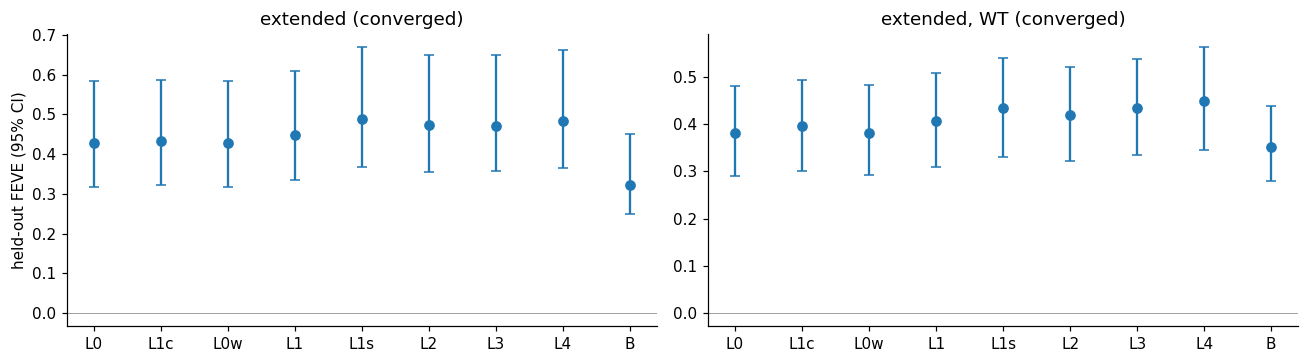

In [5]:
def full_pred(L, p):
    cols = np.arange(ds.S)
    return np.asarray(lad.predict(L, to_jnp(p), st, ds.stim, ds.strains, cfg, cols, proto=lad.proto_cols(ds, cols)))
def cv_from(L):
    out = np.zeros(ds.mean.shape)
    for f in range(len(folds)):
        msk = folds[f].reshape(folds[f].shape + (1,) * (ds.mean.ndim - 3))
        out = np.where(msk, full_pred(L, FITS[f][L]), out)
    return out
PRED = {L: cv_from(L) for L in RUNGS}
def decide(ladder, strain=None):
    point, boots = M_.bootstrap_feve(PRED, ds, list(ladder) + ["B"], n_boot=N_BOOT, seed=0, strain=strain)
    suff = M_.closure_decision(point, boots, ladder=ladder, threshold=THRESHOLD, blackbox="B")
    nec = M_.necessity(point, boots, ladder=ladder)
    v4 = {"delta=0": M_.calibrated_closure(boots, 0.0, ladder)["L_closed"]}
    v4.update({f"delta[{k}]={d:.3f}": M_.calibrated_closure(boots, d, ladder)["L_closed"] for k, d in DELTA.items()})
    return dict(point=point, boots=boots, L_star=suff["L_star"], L_needed=nec["L_needed"], v4=v4, nec=nec, suff=suff)
RES = {"E1 ladder": decide(LADDER_E1), "extended": decide(LADDER_ALL),
       "E1 ladder, WT": decide(LADDER_E1, "wt"), "extended, WT": decide(LADDER_ALL, "wt")}
per_u = M_.bootstrap_feve(PRED, ds, list(RUNGS), n_boot=200, seed=0, strain="unc31")[0] if "unc31" in ds.strains else {}
print(f"{'rung':5s}{'params':>8s}{'both':>8s}{'WT':>8s}{'unc-31':>8s}")
for L in RUNGS:
    print(f"{L:5s}{str(COUNT.get(L, '—')):>8s}{RES['extended']['point'][L]:8.3f}{RES['extended, WT']['point'][L]:8.3f}{per_u.get(L, np.nan):8.3f}")
for k, r in RES.items():
    print(f"\n{k:14s}: L* = {r['L_star']} | L_needed = {r['L_needed']} | v4 = {r['v4']}")
print(); print(M_.format_necessity(RES["extended"]["nec"]))
fin = RES["extended"]; b, pt = fin["boots"], fin["point"]
VERDICT_L0_FINAL = bool(fin["L_needed"] == "L0" and all(v == "L0" for v in fin["v4"].values()))
EQUIV = {}
print("\ndifference from L0 (both strains):")
for L in MECH[1:] + ("B",):
    d = b[L] - b["L0"]; lo, hi = np.percentile(d, [2.5, 97.5]); EQUIV[L] = dict(point=float(pt[L] - pt["L0"]), ci=[float(lo), float(hi)], equivalent=bool(lo <= 0 <= hi))
    print(f"  {L:4s} - L0: {pt[L] - pt['L0']:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  {'equivalent' if EQUIV[L]['equivalent'] else ('better' if lo > 0 else 'worse')}")
OC = {}
for k, name in (("extended", "OUTCOME_C"), ("extended, WT", "OUTCOME_C_WT")):
    r = RES[k]; Ls = r["L_star"]
    if Ls is None:
        OC[name] = False; print(f"{name}: no sufficiency L* -> rule does not apply")
    else:
        lo, hi = np.percentile(r["boots"]["B"] - r["boots"][Ls], [2.5, 97.5]); OC[name] = bool(lo > THRESHOLD)
        print(f"{name}: L* = {Ls}; FEVE(B) - FEVE(L*) = {r['point']['B'] - r['point'][Ls]:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")
print("Registered rules -> VERDICT_L0_FINAL:", VERDICT_L0_FINAL, "| OUTCOME_C:", OC["OUTCOME_C"], "| OUTCOME_C_WT:", OC["OUTCOME_C_WT"])
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
for a, k in ((ax[0], "extended"), (ax[1], "extended, WT")):
    r = RES[k]; lab = list(LADDER_ALL) + ["B"]
    mu = [r["point"][L] for L in lab]; lo = [np.percentile(r["boots"][L], 2.5) for L in lab]; hi = [np.percentile(r["boots"][L], 97.5) for L in lab]
    a.errorbar(range(len(lab)), mu, yerr=[np.subtract(mu, lo), np.subtract(hi, mu)], fmt="o", capsize=3)
    a.set_xticks(range(len(lab))); a.set_xticklabels(lab); a.set_title(k + " (converged)"); a.axhline(0, c="0.6", lw=0.6)
ax[0].set_ylabel("held-out FEVE (95% CI)"); plt.tight_layout(); plt.show()

In [6]:
out = {"source": SOURCE, "cycles": CYC, "free_parameters": COUNT, "ladder_all": list(LADDER_ALL), "converged": ALL_CONVERGED,
       "VERDICT_L0_FINAL": VERDICT_L0_FINAL, "OUTCOME_C": OC["OUTCOME_C"], "OUTCOME_C_WT": OC["OUTCOME_C_WT"], "difference_from_L0": EQUIV,
       "decisions": {k: {"feve": {L: float(v) for L, v in r["point"].items()}, "L_star": r["L_star"], "L_needed": r["L_needed"], "v4": r["v4"]}
                     for k, r in RES.items()},
       "feve_unc31": {L: float(v) for L, v in per_u.items()},
       "fits": {f"{f}/{L}": {k: v for k, v in INFO[(f, L)].items() if k != "more"} for f in range(len(folds)) for L in RUNGS}}
json.dump(out, open(os.path.join(RESULTS, f"E1p_result{TAG}.json"), "w"), indent=2, default=float)
np.savez_compressed(os.path.join(RESULTS, f"E1p_heldout_predictions{TAG}.npz"), **PRED)
print("saved", f"E1p_result{TAG}.json and E1p_heldout_predictions{TAG}.npz (the converged ladder's held-out predictions)")

saved E1p_result_laptop.json and E1p_heldout_predictions_laptop.npz (the converged ladder's held-out predictions)


## Results (laptop mode, run on the M1 Mac)

**Convergence.** Every fit converged by a rejected cycle, except `L1c` on fold 2, which still gained 0.003 in its last extra cycle. The new fits took 2–15 min each, about 4 h in total.
* L1 (grown from the converged `L1c`) accepted 0–2 cycles.
* L1s, L2, L3, L4 and B accepted 0–2 cycles each.

**Held-out FEVE, converged ladder**

| rung | free params | both strains | WT | unc-31 | − L0 (both) [95 % CI] |
|---|---|---|---|---|---|
| L0 | 126 | 0.428 | 0.381 | 0.529 | — |
| `L1c` | 345 | 0.432 | 0.396 | 0.509 | +0.004 [−0.018, +0.030] |
| `L0w` | 982 | 0.429 | 0.382 | 0.529 | +0.001 [−0.000, +0.002] |
| L1 | 1124 | 0.447 | 0.407 | 0.532 | +0.019 [−0.004, +0.047] |
| **L1s** | 1126 | **0.488** | 0.434 | **0.604** | **+0.060 [+0.037, +0.095]** |
| L2 | 1417 | 0.473 | 0.420 | 0.586 | +0.045 [+0.023, +0.077] |
| L3 | 1564 | 0.472 | 0.435 | 0.549 | +0.044 [+0.018, +0.080] |
| L4 | 1711 | 0.483 | **0.450** | 0.555 | +0.055 [+0.029, +0.094] |
| B | — | 0.322 | 0.351 | 0.259 | −0.106 [−0.186, −0.033] |

**Necessity** (extended ladder, both strains; gain over the best shallower rung):
* **L1s +0.041 [+0.027, +0.059] — needed.**
* Not needed: `L1c` +0.005, `L0w` −0.007, L1 +0.012 [−0.004, +0.025], L2 −0.016, L3 −0.016, L4 −0.004.

| ladder | L\* | L_needed | v4 (every δ) |
|---|---|---|---|
| extended, both strains | **L1s** | **L1s** | **L1s** |
| extended, WT | **L1s** | **L1s** | **L1s** |
| E1's original (L0–L4), both strains | L2 | L2 | L2 |
| E1's original, WT | L3 | L3 | L3 |

* **VERDICT_L0_FINAL = False.**
* **OUTCOME_C = False and OUTCOME_C_WT = False.** B − L\* is −0.167 [−0.255, −0.090] on both strains and −0.083 [−0.134, −0.034] on WT.

**What this means: E1's verdict changes, and for a coherent reason.**
1. **Converged, every rung with a slow process beats the wiring model by 0.04–0.06, and nothing without one does.** The four winners are:
   * L1s, a slow leak current (seconds);
   * L2, adaptation (τ ≈ 3 s);
   * L3, peptides (τ ≈ 8 s);
   * L4, homeostasis (τ ≈ 20 s).

   The rungs without slow dynamics are tied with L0: the compact sigmoid `L1c`, per-synapse weights `L0w`, and the full L1. **The data ask for a slow process, not for a particular mechanism.** Among the slow rungs, the one with the fewest parameters (L1s, 2 more than L1) is as good as or better than the rest. The richer ones add nothing beyond it, and L2 and L3 are slightly worse.
2. **This is Notebook 19's observation, now at full strength.** The slow current's gain over L1 grew from +0.025 (fixed-budget fits) to +0.041 converged, and it appears in every slow mechanism. The earlier verdict "L0" came from comparing the slow rungs before they were converged: Notebook 25's fixed budget left them 0.1 low.
3. **The effect is largest without neuropeptide release:** unc-31 L1s 0.604 vs L0 0.529. On WT the slow rungs gain about +0.05 (L4 0.450, L3 0.435, L1s 0.434 vs L0 0.381).
4. **The black box remains far behind** (0.32), so outcome A/B holds. What predicts the responses is mechanistic, and it includes slow dynamics.
5. **Two caveats before the claim is final:**
   * **The inner validation split did not see the gain.** On 4 of 5 folds the inner validation loss of L1s was not lower than L1's, while the outer test FEVE is clearly higher. The training loss weights pairs by their inverse noise variance, but FEVE pools them unweighted. The two metrics rank models differently, so the cycles were accepted or rejected on a criterion that is not quite the one decided on.
   * **The cheapest slow models were not on this ladder.** The linear wiring model with the slow current (`L0s`, 128 parameters) and the compact sigmoid model with it (`L1cs`, 347) were missing. If "wiring + one slow process" suffices, the closed level is far simpler than L1s.
6. **Notebook 30 (E1q)** fits `L0s` and `L1cs` to convergence the same way, adds them to this ladder and decides once more. Which is the cheapest slow model the data accept?

> **Follow-up (Notebook 30).** Of the cheaper slow models, `L0s` gains only +0.012 over L0 and `L1cs` only +0.006 over `L1c`. Both stay about 0.05 below L1s, so point 5's "far simpler closed level" is not supported. The slow current needs per-synapse weights to show its effect.

## 3 · Reading the result

| VERDICT_L0_FINAL | richer rungs | reading for C2 (E1, final) |
|---|---|---|
| yes | all equivalent to L0 | **Closed at L0, with a family of equivalent descriptions.** Converged, every mechanism predicts single-neuron-stimulation responses as well as the linear wiring model, and none better. The richer mechanisms are not *wrong*; the data do not need them. E1 names the simplest. |
| yes | some worse than L0 even converged | As above. The worse rungs over-fit or are hard to optimize even by cycles; their losses are not evidence against the mechanisms. |
| no | a richer rung beats L0 | **← observed (L1s; every slow rung beats L0).** **A mechanism above the wiring is needed** once every rung is converged; the necessity table names it. This would reverse Notebooks 25–28. Confirm it with the experimental design of Notebook 08. |

| OUTCOME_C (both / WT) | reading |
|---|---|
| no / no | **← observed** (B is 0.08–0.17 below L\*). Whatever predicts the responses is captured by the mechanistic ladder: outcome A/B. |
| any yes | A converged black box beats the closed level by E1's margin: **outcome C**. Something systematic is missed. |

**Limits.**
* Every fit uses 80 % of the training pairs; Notebook 28 showed this costs nothing for L0.
* The chain grows from `L1c`, so L1–L4 inherit its basin. Other basins are not explored; E1's original fits came from 3 random L1 starts.
* `laptop` mode is the 120 most-sampled neurons. The registered E1 test (`full`, 300 neurons) would repeat Notebooks 28–29 on a GPU.